# Analysis of tissue composition of archetypes


This code calculates the relative distance of each cell within the gene expression space to all archetypes.
Identifies the archetype to which each cell is most closely associated.
It generates plots that describe the relationships between tissues and archetypes, based on these associations.

 Input Files:
1. arcOrig.mat : Contains the coordinates of the archetypes in the original gene expression space. ("Mac_5_arcOrig.mat")
2. Gene Expression Matrix: The cells in the original gene space, the input of the ParTI.. ("HighV_logZ.csv" or adata like "High_Var_Norm_macro.h5ad")
3. Metadata File : Contains information on the tissue identity of each cell. ("macro_meta.csv" or adata.obs)

In [1]:
import os
from pathlib import Path
import pathlib

import anndata as ad
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output, Markdown
import re
from ipywidgets import interact
import ipywidgets as widgets
from sklearn.decomposition import PCA
from adjustText import adjust_text

%matplotlib inline

INPUT_ROOT = Path(os.environ["PUBLICATION_INPUT_ROOT"]).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ["PUBLICATION_OUTPUT_ROOT"]).expanduser().resolve()
FIG3_DIR = INPUT_ROOT / "01_ParTI_results"
RESULTS_DIR = OUTPUT_ROOT / "Figure_3_Composition"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def validate_expression_archetypes(adata, archetypes, expected_archetypes, label):
    if archetypes.shape[0] != expected_archetypes:
        raise ValueError(
            f"{label}: expected {expected_archetypes} archetypes, got {archetypes.shape[0]}"
        )
    if adata.n_vars != archetypes.shape[1]:
        raise ValueError(
            f"{label}: H5AD has {adata.n_vars} genes but arcOrig has {archetypes.shape[1]}"
        )
    print(
        f"Validated {label}: cells={adata.n_obs}, genes={adata.n_vars}, "
        f"archetypes={archetypes.shape[0]}"
    )


## functions

### calculate function

In [2]:
def calculate_archetype_weights(point, archetypes):
    """
    Calculate the weights of a point relative to a set of archetypes.
    
    Args:
        point (np.array): Gene expression matrix.
        archetypes (np.array): Matrix of archetype coordinates.
        
    Returns:
        np.array: Normalized weights summing to 1.
    """
    if archetypes.shape[1] != len(point):
        raise ValueError(
            f"Mismatch in dimensions: archetypes have {archetypes.shape[1]} features, "
            f"but point has {len(point)} features."
        )

    # Extend archetypes and point for homogeneous coordinates
    extended_archetypes = np.hstack((archetypes, np.ones((archetypes.shape[0], 1))))
    extended_point = np.append(point, 1)

    # Compute A and b
    A = np.dot(extended_archetypes, extended_archetypes.T)
    b = np.dot(extended_archetypes, extended_point)

    # Solve for weights
    weights = np.linalg.solve(A, b)
    return weights / np.sum(weights) 

def process_weights(gene_expression, archetypes, metadata, tissue_col, archetype_prefix):
    """
    Process gene expression data to calculate archetype weights and format into a DataFrame.
    """
    # Calculate weights
    weights_np = np.apply_along_axis(
        calculate_archetype_weights,
        1,
        np.asarray(gene_expression),
        archetypes
    )
    
    # Create DataFrame
    weights_df = pd.DataFrame(
        weights_np, 
        columns=[f"{archetype_prefix}_{i+1}" for i in range(archetypes.shape[0])],
        index=metadata.index
    )
    
    weights_df.columns = [f"Archetype_{i+1}" for i in range(archetypes.shape[0])]
    
    weights_df['Max_Weight'] = weights_df.max(axis=1)
    weights_df['Dominant_Archetype'] = weights_df.idxmax(axis=1)
    
    # This assumes metadata and weights_df are row-aligned, which they are by construction.
    weights_df['Tissue'] = metadata[tissue_col].values
    
    return weights_df


In [3]:
def _extract_archetype_int(value) -> int:
    if pd.isna(value):
        return 0

    if isinstance(value, (int, np.integer, float, np.floating)):
        return int(value)

    value_str = str(value).strip()

    if value_str == "-1":
        return -1

    m = re.search(r"(?:archetype|arc|am|af|ae)[ _]?(\d+)", value_str, re.IGNORECASE)
    return int(m.group(1)) if m else 0

def calculate_tables(df: pd.DataFrame, threshold: float = 0.5, generalist_threshold: float = 0.3):
    """
    Returns normalized summary DataFrames for plotting.

    Classification:
    - Max_Weight >= threshold: assigned to dominant archetype
    - Max_Weight < generalist_threshold: generalist (archetype 0)
    - generalist_threshold <= Max_Weight < threshold: discarded
    """
    df = df.copy()

    # Normalize tissue names
    df["Tissue"] = (
        df["Tissue"]
        .astype(str)
        .str.strip()
        .str.replace("_", " ", regex=False)
    )

    df["Tissue"] = df["Tissue"].replace({
        "Small intestine": "Small Intestine",
        "Large intestine": "Large Intestine",
        "Bone Marrow": "Bone marrow",
        "Limb muscle": "Limb Muscle",
        "Mammary gland": "Mammary Gland",
    })

    # Assign archetypes / generalists / discarded cells
    df["archetype_raw"] = np.where(
        df["Max_Weight"] >= threshold,
        df["Dominant_Archetype"],
        np.where(df["Max_Weight"] < 0.3, 0, -1)
    )

    # Convert labels to integer archetype ids
    df["archetype"] = df["archetype_raw"].map(_extract_archetype_int).astype(int)

    # Normalize by remaining tissue counts
    tissue_counts = df["Tissue"].value_counts().to_dict()

    def build_stats(group_col, value_col):
        rows = sorted(df[group_col].unique())
        cols = sorted(df[value_col].unique())

        idx = pd.MultiIndex.from_product([rows, cols], names=[group_col, value_col])

        counts = (
            df.groupby([group_col, value_col], observed=True)
            .size()
            .reindex(idx, fill_value=0)
            .reset_index(name="Count")
        )

        totals = counts["Tissue"].map(tissue_counts).fillna(0)

        counts["Adjusted_Count"] = np.where(
            totals > 0,
            (counts["Count"] * 1000) / totals,
            0
        )

        counts["Percentage"] = counts.groupby(group_col)["Adjusted_Count"].transform(
            lambda x: 100 * x / x.sum() if x.sum() > 0 else 0
        )

        return counts

    arch_summary = build_stats(group_col="archetype", value_col="Tissue")
    tissue_summary = build_stats(group_col="Tissue", value_col="archetype")

    return arch_summary, tissue_summary

In [4]:
def calculate_gini(df_input, threshold=0.5):
    """
    Calculates normalized Gini-Simpson Index (0 to 1 range).
    """
    arch_data, _ = calculate_tables(df_input, threshold)
    df_filtered = arch_data.copy()

    n_tissues = df_filtered["Tissue"].nunique()
    max_theoretical_gini = 1 - (1 / n_tissues)

    gini_scores = {}
    for arch_id in sorted(df_filtered["archetype"].unique()):
        subset = df_filtered[df_filtered["archetype"] == arch_id]
        proportions = subset["Percentage"] / 100.0
        raw_gini = 1 - (proportions ** 2).sum()
        gini_scores[arch_id] = raw_gini / max_theoretical_gini

    return pd.Series(gini_scores)

def run_pca_calculation(
    df_input,
    threshold=0.5,
    include_generalists=False,
    n_components=2
):
    """
    Performs PCA on tissue-by-archetype composition data.

    Rules:
    - Semi-specialists (-1) are always excluded from PCA.
    - Generalists (0) are included only if include_generalists=True.
    - After removing columns, each tissue is renormalized to sum to 1.
    """
    _, tissue_data = calculate_tables(df_input, threshold)

    pivot_df = (
        tissue_data
        .pivot(index="Tissue", columns="archetype", values="Percentage")
        .fillna(0)
    )

    # Convert percentages to fractions
    pivot_df = pivot_df / 100.0

    # Always remove semi-specialists from PCA
    if -1 in pivot_df.columns:
        pivot_df = pivot_df.drop(columns=[-1])

    # Remove generalists only if requested
    if not include_generalists and 0 in pivot_df.columns:
        pivot_df = pivot_df.drop(columns=[0])

    # Renormalize each tissue after filtering
    row_sums = pivot_df.sum(axis=1)
    pivot_df = pivot_df.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

    # PCA cannot have more components than min(n tissues, n features)
    max_components = min(pivot_df.shape[0], pivot_df.shape[1])
    n_components = min(n_components, max_components)

    pca = PCA(n_components=max_components)
    coords = pca.fit_transform(pivot_df)
    var_exp = pca.explained_variance_ratio_ * 100

    return coords, var_exp, pivot_df.index

In [5]:
def get_pc1_values(
    df,
    threshold,
    drop_generalists=True,
    drop_semi_specialists=True
):
    """
    Calculates PC1 for a single cell type dataframe.
    """
    _, tissue_data = calculate_tables(df, threshold)

    pivot_df = (
        tissue_data
        .pivot(index="Tissue", columns="archetype", values="Percentage")
        .fillna(0)
    )

    if drop_semi_specialists and -1 in pivot_df.columns:
        pivot_df = pivot_df.drop(columns=[-1])

    if drop_generalists and 0 in pivot_df.columns:
        pivot_df = pivot_df.drop(columns=[0])

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(pivot_df)[:, 0]

    return pd.Series(pc1, index=pivot_df.index)

def calculate_averaged_pc1(macro_df, fibro_df, endo_df, threshold=0.5, include_generalists=False):
    s1 = get_pc1_values(macro_df, threshold, include_generalists=include_generalists).rename("Macro")
    s2 = get_pc1_values(fibro_df, threshold, include_generalists=include_generalists).rename("Fibro")
    s3 = get_pc1_values(endo_df, threshold, include_generalists=include_generalists).rename("Endo")

    combined = pd.concat([s1, s2, s3], axis=1)

    if combined["Macro"].corr(combined["Fibro"]) < 0:
        combined["Fibro"] *= -1

    if combined["Macro"].corr(combined["Endo"]) < 0:
        combined["Endo"] *= -1

    combined["Mean_PC1"] = combined.mean(axis=1)

    return combined["Mean_PC1"].sort_values()

### visualization functions

In [6]:
TARGET_TISSUE_ORDER = [
    "Kidney",
    "Pancreas",
    "Heart",
    "Tongue",
    "Thymus",
    "Lung",
    "Liver",
    "Bladder",
    "Spleen",
    "Small Intestine",
    "Small_intestine",
    "Trachea",
    "Stomach",
    "Fat",
    "Muscle",
    "Limb Muscle",
    "Limb muscle",
    "Large Intestine",
    "Large_intestine",
    "Skin",

    # not shown in this plot, keep at end
    "Marrow",
    "Bone marrow",
    "Bone_Marrow",
    "Mammary Gland",
    "Mammary gland",
    "Mammary",
]

TISSUE_PALETTE = {
    "Bladder": "#3953A4",
    "Fat": "#ED2024",
    "Heart": "#6ABD45",
    "Kidney": "#0F1031",

    "Large Intestine": "#E03F97",
    "Large_intestine": "#E03F97",

    "Liver": "#1F5429",
    "Lung": "#FED304",
    "Pancreas": "#4996D2",
    "Skin": "#9A4D42",

    "Small Intestine": "#DF7D26",
    "Small_intestine": "#DF7D26",

    "Spleen": "#714EA0",
    "Thymus": "#1E9698",
    "Tongue": "#E3AFD1",
    "Trachea": "#A93493",

    # aliases for the exact names appearing in your plot
    "Marrow": "#A781BA",
    "Bone marrow": "#A781BA",
    "Bone_Marrow": "#A781BA",

    "Limb Muscle": "#18BDC2",
    "Limb muscle": "#18BDC2",

    "Mammary Gland": "#C29A2D",
    "Mammary gland": "#C29A2D",
    "Mammary": "#C29A2D",

    "Stomach": "#C49A6C",
    "Muscle": "#5C8A00",
}

ARCHETYPE_PALETTE = {
    1: "#FFFF33",
    2: "#377EB8",
    3: "#4DAF4A",
    4: "#E41A1C",
    5: "#984EA3",
    6: "#FF7F00",
    0: "#808080",
}

MAIN_TISSUE_ALIASES = {
    "Small_intestine": "Small Intestine",
    "small_intestine": "Small Intestine",
    "small intestine": "Small Intestine",

    "Large_intestine": "Large Intestine",
    "large_intestine": "Large Intestine",
    "large intestine": "Large Intestine",

    "Limb Muscle": "Muscle",
    "Limb muscle": "Muscle",
    "Mammary Gland": "Mammary Gland",
    "Mammary gland": "Mammary Gland",
    "Mammary": "Mammary Gland",
    "Bone marrow": "Marrow",
}

MAIN_TISSUE_ORDER = [
    "Kidney",
    "Pancreas",
    "Heart",
    "Tongue",
    "Thymus",
    "Lung",
    "Liver",
    "Bladder",
    "Spleen",
    "Large Intestine",
    "Trachea",
    "Stomach",
    "Fat",
    "Muscle",
    "Small Intestine",
    "Skin",
]

In [7]:
def _archetype_label(arch_id, prefix="AM"):
    """
    Format archetype labels for plots.
    """
    arch_id = int(arch_id)

    if arch_id == -1:
        return "Semi-specialists"
    if arch_id == 0:
        return "Generalists"

    return f"{prefix}{arch_id}"


def _threshold_tag(threshold):
    """
    Convert threshold value into filename-safe tag.
    Example: 0.5 -> thr0p50
    """
    return f"thr{threshold:.2f}".replace(".", "p")


def _prepare_save_path(save_path):
    """
    Prepare save directory.
    If save_path is None, save to current working directory.
    """
    if save_path is None:
        save_path = pathlib.Path(".")
    else:
        save_path = pathlib.Path(save_path)

    save_path.mkdir(parents=True, exist_ok=True)
    return save_path


def plot_tissues(
    df_input,
    threshold=0.5,
    prefix="AM",
    save_path=None,
    include_generalists=False,
    include_semi_specialists=False
):
    """
    Plot tissue composition per archetype.
    Saves:
    - PDF figure
    - CSV pivot table used for plotting
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    arch_data, _ = calculate_tables(df_input, threshold)
    plot_data = arch_data.copy()

    if not include_generalists:
        plot_data = plot_data[plot_data["archetype"] != 0].copy()
    if not include_semi_specialists:
        plot_data = plot_data[plot_data["archetype"] != -1].copy()

    pivot_df = (
        plot_data
        .pivot(index="archetype", columns="Tissue", values="Percentage")
        .fillna(0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(5, 6))
    seen_tissues = set()

    for x_pos, (arch_id, row) in enumerate(pivot_df.iterrows()):
        sorted_row = row.sort_values(ascending=False)
        current_bottom = 0

        for tissue, pct in sorted_row.items():
            if pct > 0:
                ax.bar(
                    x=x_pos,
                    height=pct,
                    bottom=current_bottom,
                    color=TISSUE_PALETTE.get(tissue, "#999999"),
                    edgecolor="black",
                    linewidth=0.5,
                    width=0.85
                )
                current_bottom += pct
                seen_tissues.add(tissue)

    ax.set_title(f"Thresh: {threshold:.2f}", fontsize=12)
    ax.set_ylabel("Tissue composition (%)", fontsize=12)

    ax.set_xticks(range(len(pivot_df)))
    ax.set_xticklabels(
        [_archetype_label(i, prefix=prefix) for i in pivot_df.index],
        fontsize=11,
        rotation=45,
        ha="right"
    )

    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ordered_seen = [t for t in TARGET_TISSUE_ORDER if t in seen_tissues]
    leftovers = sorted([t for t in seen_tissues if t not in ordered_seen])
    legend_tissues = ordered_seen + leftovers

    patches = [
        mpatches.Patch(
            color=TISSUE_PALETTE.get(t, "#999999"),
            label=t.replace("_", " ")
        )
        for t in legend_tissues
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False,
        title="Tissue"
    )

    plt.tight_layout()

    suffix = "with_generalists" if include_generalists else "no_generalists"

    pdf_path = save_path / f"tissue_composition_{prefix}_{tag}_{suffix}.pdf"
    csv_path = save_path / f"tissue_composition_{prefix}_{tag}_{suffix}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")
    pivot_df.to_csv(csv_path)

    display(fig)
    plt.close(fig)

    return pivot_df

def plot_archetypes(
    df_input,
    threshold=0.5,
    prefix="AM",
    save_path=None,
    include_generalists=True,
    hide_semi_specialists=True
):
    """
    Plot archetype composition per tissue.

    Assumes these are defined globally:
    - MAIN_TISSUE_ALIASES
    - MAIN_TISSUE_ORDER
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    _, tissue_data = calculate_tables(df_input, threshold)
    plot_data = tissue_data.copy()

    # Collapse tissue aliases to main tissue names
    plot_data["Tissue"] = plot_data["Tissue"].replace(MAIN_TISSUE_ALIASES)

    # Keep only the selected main tissues
    plot_data = plot_data[plot_data["Tissue"].isin(MAIN_TISSUE_ORDER)].copy()

    # Hide semi-specialists before plotting
    if hide_semi_specialists:
        plot_data = plot_data[plot_data["archetype"] != -1].copy()

    # Optional: hide generalists
    if not include_generalists:
        plot_data = plot_data[plot_data["archetype"] != 0].copy()

    # Use pivot_table because aliases may collapse several rows into one tissue
    pivot_df = (
        plot_data
        .pivot_table(
            index="Tissue",
            columns="archetype",
            values="Percentage",
            aggfunc="sum",
            fill_value=0
        )
    )

    # Force fixed tissue order and keep missing tissues as empty rows
    pivot_df = pivot_df.reindex(MAIN_TISSUE_ORDER).fillna(0)

    # Identify tissues with no visible cells after filtering
    row_sums = pivot_df.sum(axis=1)
    missing_tissues = row_sums[row_sums == 0].index.tolist()

    # Renormalize visible categories to 100%; keep missing tissues at 0
    pivot_df = pivot_df.div(row_sums.replace(0, np.nan), axis=0) * 100
    pivot_df = pivot_df.fillna(0)

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(pivot_df))
    bottoms = np.zeros(len(pivot_df))

    arch_cols = sorted(pivot_df.columns, key=lambda a: int(a))

    for arch_id in arch_cols:
        arch_int = int(arch_id)

        values = pivot_df[arch_id].values
        label = _archetype_label(arch_int, prefix=prefix)
        color = ARCHETYPE_PALETTE.get(arch_int, "#999999")

        ax.bar(
            x,
            values,
            bottom=bottoms,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            width=0.8
        )

        bottoms += values

    # Draw missing tissues as hatched empty columns
    for tissue in missing_tissues:
        x_pos = list(pivot_df.index).index(tissue)

        ax.bar(
            x_pos,
            100,
            bottom=0,
            color="lightgray",
            edgecolor="black",
            linewidth=0.5,
            width=0.8,
            hatch="//",
            label="_nolegend_"
        )

    ax.set_title(f"Thresh: {threshold:.2f}", fontsize=12)
    ax.set_ylabel("Archetype composition among visible cells (%)", fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(
        pivot_df.index,
        rotation=45,
        ha="right",
        fontsize=11
    )

    ax.set_ylim(0, 100)
    ax.set_xlim(-0.6, len(pivot_df) - 0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()

    if handles:
        ax.legend(
            reversed(handles),
            reversed(labels),
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            frameon=False
        )

    plt.tight_layout()

    pdf_path = save_path / f"archetype_composition_{prefix}_{tag}.pdf"
    csv_path = save_path / f"archetype_composition_{prefix}_{tag}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")
    pivot_df.to_csv(csv_path)

    display(fig)
    plt.close(fig)

    return pivot_df


def plot_gini(
    df_input,
    threshold=0.5,
    prefix="AM",
    save_path=None,
    include_generalists=False,
    include_semi_specialists=False
):
    """
    Plot Gini-Simpson index per archetype.
    Saves:
    - PDF figure
    - CSV values used for plotting
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    gini_scores = calculate_gini(df_input, threshold)

    if not include_generalists and 0 in gini_scores.index:
        gini_scores = gini_scores.drop(index=0)

    if not include_semi_specialists and -1 in gini_scores.index:
        gini_scores = gini_scores.drop(index=-1)

    fig, ax = plt.subplots(figsize=(4, 5))

    ax.bar(
        range(len(gini_scores)),
        gini_scores.values,
        color="#D3D3D3",
        edgecolor="black",
        linewidth=1.0,
        width=0.7
    )

    ax.set_ylabel("Gini-Simpson index", fontsize=12)
    ax.set_ylim(0, 1.05)

    ax.set_xticks(range(len(gini_scores)))
    ax.set_xticklabels(
        [_archetype_label(i, prefix=prefix) for i in gini_scores.index],
        fontsize=11,
        rotation=45,
        ha="right"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()


    pdf_path = save_path / f"gini_index_{prefix}_{tag}.pdf"
    csv_path = save_path / f"gini_index_{prefix}_{tag}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")

    gini_df = (
        gini_scores
        .rename("Gini_Simpson")
        .reset_index()
        .rename(columns={"index": "archetype"})
    )
    gini_df["label"] = gini_df["archetype"].map(lambda x: _archetype_label(x, prefix=prefix))
    gini_df.to_csv(csv_path, index=False)

    display(fig)
    plt.close(fig)

    return gini_scores


def draw_pca_plot(
    coords,
    var_exp,
    tissue_names,
    threshold,
    save_path=None,
    prefix="AM",
    cell_type_prefix="celltype",
    include_generalists=False
):
    """
    Draw PCA plot.
    Saves:
    - PDF figure
    - CSV PCA coordinates used for plotting
    """
    plt.close("all")

    save_path = _prepare_save_path(save_path)
    tag = _threshold_tag(threshold)

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c="black",
        s=40
    )

    texts = []
    for i, txt in enumerate(tissue_names):
        texts.append(
            ax.text(
                coords[i, 0],
                coords[i, 1],
                txt,
                fontsize=11
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

    ax.set_xlabel(f"PC1 ({var_exp[0]:.0f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({var_exp[1]:.0f}%)", fontsize=12)
    ax.set_title(f"Thresh: {threshold:.2f}", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()

    pdf_path = save_path / f"pca_plot_{cell_type_prefix}_{tag}.pdf"
    csv_path = save_path / f"pca_plot_{cell_type_prefix}_{tag}.csv"

    fig.savefig(pdf_path, bbox_inches="tight")

    pca_df = pd.DataFrame({
        "Tissue": list(tissue_names),
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "PC1_variance_percent": var_exp[0],
        "PC2_variance_percent": var_exp[1],
        "threshold": threshold,
        "include_generalists": include_generalists,
    })

    pca_df.to_csv(csv_path, index=False)

    display(fig)
    plt.close(fig)

    return pca_df


def interactive_pca_wrapper(
    df_input,
    threshold=0.5,
    save_path=None,
    cell_type_prefix="celltype",
    include_generalists=False
):
    """
    Run PCA calculation and plot PCA.
    Saves:
    - PDF PCA figure
    - CSV PCA coordinates
    """
    coords, var, names = run_pca_calculation(
        df_input,
        threshold=threshold,
        include_generalists=include_generalists
    )

    pca_df = draw_pca_plot(
        coords=coords,
        var_exp=var,
        tissue_names=names,
        threshold=threshold,
        save_path=save_path,
        cell_type_prefix=cell_type_prefix,
        include_generalists=include_generalists
    )

    return pca_df

## macrophage data

### Load Data

In [8]:
# Load Macrophage Data
mac_path = FIG3_DIR / "macrophages"
adata_path = mac_path / "normalized_macrophages.h5ad"
RESULTS_MACROPHAGES_DIR = RESULTS_DIR / "macrophage"
RESULTS_MACROPHAGES_DIR.mkdir(parents=True, exist_ok=True)

adata = ad.read_h5ad(adata_path)
gene_expression_data = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
archetypes_data = loadmat(mac_path / "macro_arcOrig.mat")["arcOrig"]
metadata = adata.obs
validate_expression_archetypes(adata, archetypes_data, 5, "human macrophage")


Validated human macrophage: cells=13423, genes=8114, archetypes=5


### calculate weights


In [9]:
macrophage_weights = process_weights(
    gene_expression_data,
    archetypes_data,
    metadata,
    'tissue_in_publication',
    'Archetype'
)


In [10]:
macrophage_weights.head()
macrophage_weights.to_csv(RESULTS_DIR / "macrophage_archetype_weights.csv", index=True)

###  Tissue composition plots

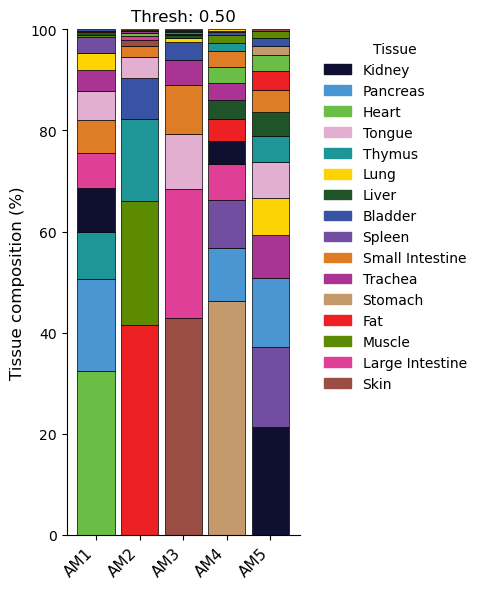

Tissue,Bladder,Fat,Heart,Kidney,Large Intestine,Liver,Lung,Muscle,Pancreas,Skin,Small Intestine,Spleen,Stomach,Thymus,Tongue,Trachea
archetype,,,,,,,,,,,,,,,,
1,0.258654,0.258654,32.419825,8.704696,6.915878,0.517308,3.362500,0.517308,18.142051,0.000000,6.408090,3.103846,0.000000,9.423318,5.837040,4.130835
2,8.130930,41.519643,0.471386,0.000000,0.925126,0.172999,0.172999,24.565789,0.000000,1.047418,2.337818,0.000000,0.000000,16.082776,4.148060,0.425058
3,3.370307,0.187239,0.000000,0.000000,25.532626,0.561718,0.936196,0.280859,0.000000,42.889316,9.699331,0.280859,0.121112,0.235225,10.959703,4.945509
4,0.537926,4.303408,3.297912,4.525820,7.191525,3.765482,0.268963,1.613778,10.510579,0.271406,3.028863,9.413706,46.276951,1.689466,0.000000,3.304214
5,1.477701,3.842022,3.019825,21.312993,0.000000,4.728643,7.388504,1.477701,13.622092,0.298224,4.326602,15.959169,1.911644,5.197943,7.086295,8.350644


In [11]:
plot_tissues(macrophage_weights, threshold=0.5, prefix='AM', save_path=RESULTS_MACROPHAGES_DIR)


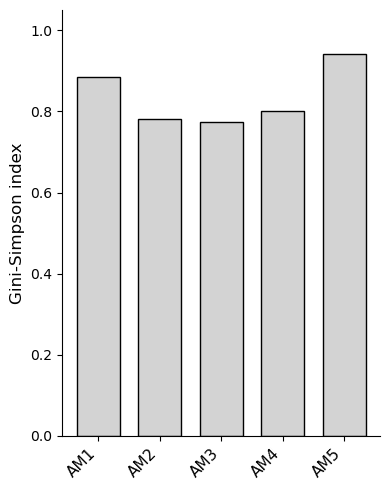

1    0.884652
2    0.781097
3    0.774094
4    0.801877
5    0.941960
dtype: float64

In [12]:
plot_gini(macrophage_weights, threshold=0.5, prefix='AM', save_path=RESULTS_MACROPHAGES_DIR)


### Archetype  composition per tissue

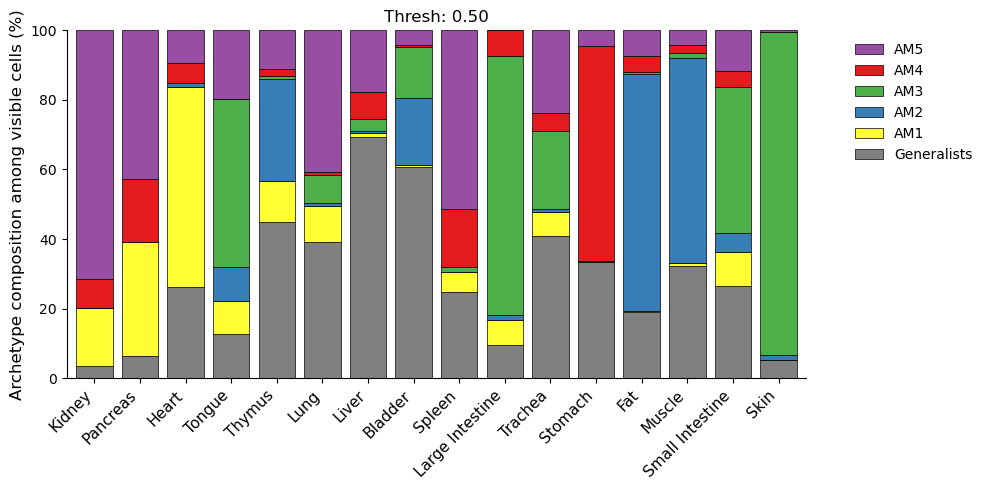

archetype,0,1,2,3,4,5
Tissue,,,,,,
Kidney,3.571429,16.666667,0.000000,0.000000,8.333333,71.428571
Pancreas,6.511628,32.558140,0.000000,0.000000,18.139535,42.790698
Heart,26.250000,57.500000,1.250000,0.000000,5.625000,9.375000
Tongue,12.790698,9.302326,9.883721,48.255814,0.000000,19.767442
Thymus,45.019920,11.553785,29.482072,0.796813,1.992032,11.155378
Lung,39.024390,10.569106,0.813008,8.130081,0.813008,40.650407
Liver,69.444444,1.111111,0.555556,3.333333,7.777778,17.777778
Bladder,60.816327,0.408163,19.183673,14.693878,0.816327,4.081633
Spleen,24.761905,5.714286,0.000000,1.428571,16.666667,51.428571


In [13]:
plot_archetypes(macrophage_weights, include_generalists=True, threshold=0.5, prefix='AM', save_path=RESULTS_MACROPHAGES_DIR)


### PCA of archetype composition

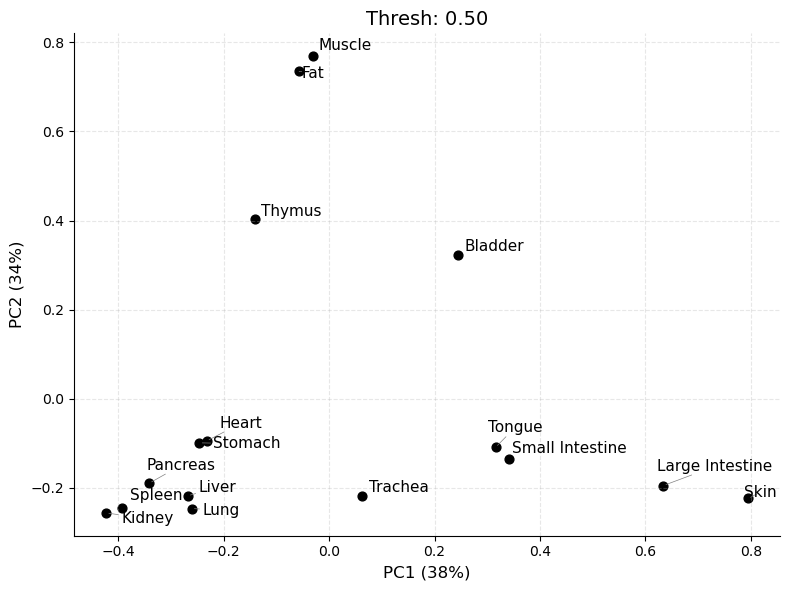

In [14]:
pca_df_macro = interactive_pca_wrapper(
    macrophage_weights,
    threshold=0.5,
    save_path=RESULTS_MACROPHAGES_DIR,
    cell_type_prefix="macrophage",
    include_generalists=False
)

In [15]:
pca_df_macro

,Tissue,PC1,PC2,PC1_variance_percent,PC2_variance_percent,threshold,include_generalists
0,Bladder,0.244138,0.322772,37.958118,34.440147,0.5,False
1,Fat,-0.057029,0.734871,37.958118,34.440147,0.5,False
2,Heart,-0.232516,-0.094759,37.958118,34.440147,0.5,False
3,Kidney,-0.423194,-0.256087,37.958118,34.440147,0.5,False
4,Large Intestine,0.634293,-0.194732,37.958118,34.440147,0.5,False
5,Liver,-0.268350,-0.217620,37.958118,34.440147,0.5,False
6,Lung,-0.260803,-0.246312,37.958118,34.440147,0.5,False
7,Muscle,-0.030142,0.769070,37.958118,34.440147,0.5,False
8,Pancreas,-0.341346,-0.189427,37.958118,34.440147,0.5,False
9,Skin,0.794699,-0.223725,37.958118,34.440147,0.5,False


## Fibroblast data

### load data

In [16]:
# Load Fibroblast Data
fibro_path = FIG3_DIR / 'fibroblasts'
adata_fibro_path = FIG3_DIR / 'fibroblasts' / 'normalized_fibroblast.h5ad'
RESULTS_FIBROBLASTS_DIR = RESULTS_DIR / "fibroblast"
RESULTS_FIBROBLASTS_DIR.mkdir(parents=True, exist_ok=True)


adata_fibro = ad.read_h5ad(adata_fibro_path)
gene_expression_fibro = adata_fibro.X if isinstance(adata_fibro.X, np.ndarray) else adata_fibro.X.toarray()
archetypes_data_fibro = loadmat(fibro_path / 'fibro_arcOrig.mat')['arcOrig']
Fibro_meta = adata_fibro.obs
validate_expression_archetypes(adata_fibro, archetypes_data_fibro, 4, "human fibroblast")


Validated human fibroblast: cells=10899, genes=11900, archetypes=4


## calculate weights

In [17]:
fibroblasts_weights = process_weights(
    gene_expression_fibro,
    archetypes_data_fibro,
    Fibro_meta,
    'tissue_in_publication',
    'Archetype'
)


In [18]:
fibroblasts_weights.head()

,Archetype_1,Archetype_2,Archetype_3,Archetype_4,Max_Weight,Dominant_Archetype,Tissue
0,0.452122,0.214446,0.067732,0.265700,0.452122,Archetype_1,Lung
1,0.329248,0.220223,0.054549,0.395981,0.395981,Archetype_4,Lung
2,0.461212,0.236677,0.035732,0.266379,0.461212,Archetype_1,Lung
3,0.238493,0.187209,0.176949,0.397349,0.397349,Archetype_4,Lung
4,0.432880,0.206114,0.042474,0.318532,0.432880,Archetype_1,Lung


In [19]:
fibroblasts_weights.head()
fibroblasts_weights.shape
fibroblasts_weights.to_csv(RESULTS_DIR / "fibroblast_archetype_weights.csv", index=True)


## tissue composition plots

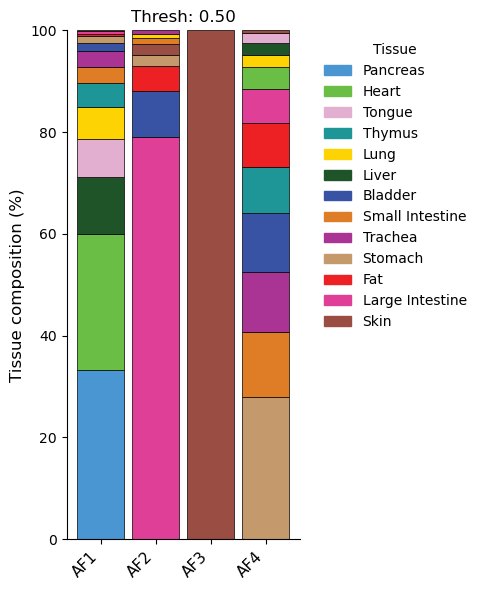

Tissue,Bladder,Fat,Heart,Large Intestine,Liver,Lung,Pancreas,Skin,Small Intestine,Stomach,Thymus,Tongue,Trachea
archetype,,,,,,,,,,,,,
1,1.713126,0.548200,26.827547,0.445413,11.066153,6.338565,33.202847,0.205575,3.275093,1.199188,4.625439,7.537753,3.015101
2,9.165371,4.935200,0.000000,78.963193,0.000000,0.705029,0.000000,2.115086,1.296008,2.115086,0.000000,0.000000,0.705029
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,11.569169,8.676877,4.338439,6.778810,2.245569,2.349988,0.000000,0.451921,12.793343,27.928698,9.038414,2.078835,11.749938


In [20]:
plot_tissues(fibroblasts_weights, threshold=0.5, prefix='AF', save_path=RESULTS_FIBROBLASTS_DIR)


### Gini plots

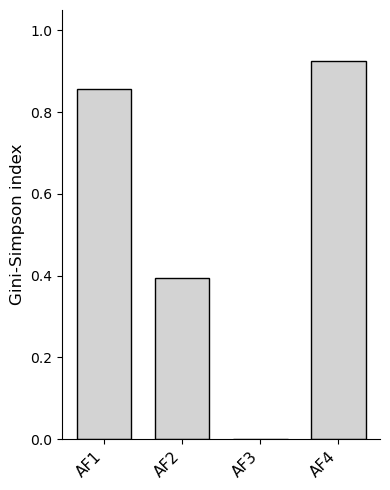

1    0.857163
2    0.394857
3    0.000000
4    0.925986
dtype: float64

In [21]:
plot_gini(fibroblasts_weights, threshold=0.5, prefix='AF', save_path=RESULTS_FIBROBLASTS_DIR)


### archetype composition per tissue

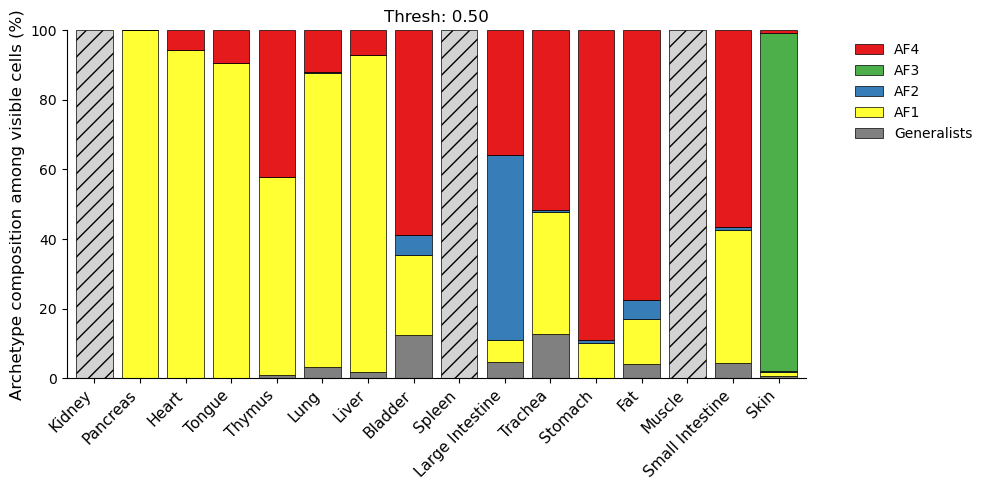

archetype,0,1,2,3,4
Tissue,,,,,
Kidney,0.000000,0.000000,0.000000,0.000000,0.000000
Pancreas,0.000000,100.000000,0.000000,0.000000,0.000000
Heart,0.000000,94.223827,0.000000,0.000000,5.776173
Tongue,0.000000,90.534979,0.000000,0.000000,9.465021
Thymus,0.843882,56.962025,0.000000,0.000000,42.194093
Lung,3.196347,84.474886,0.456621,0.000000,11.872146
Liver,1.754386,91.228070,0.000000,0.000000,7.017544
Bladder,12.385321,22.935780,5.963303,0.000000,58.715596
Spleen,0.000000,0.000000,0.000000,0.000000,0.000000


In [22]:
plot_archetypes(fibroblasts_weights, include_generalists=True, threshold=0.5, prefix='AF', save_path=RESULTS_FIBROBLASTS_DIR)


### PCA of archetype composition

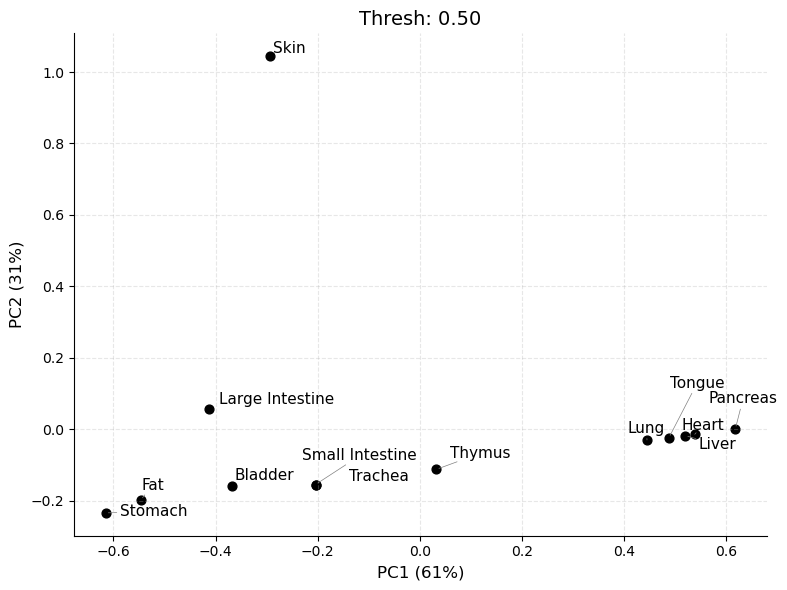

In [23]:
pca_df_fibro = interactive_pca_wrapper(
    fibroblasts_weights,
    threshold=0.5,
    save_path=RESULTS_FIBROBLASTS_DIR,
    cell_type_prefix="fibroblasts",
    include_generalists=False
)

## Endothelial data

### load data

In [24]:
# Load Endothelial Data
endo_path = FIG3_DIR / 'endothelial'
adata_endo_path = FIG3_DIR / 'endothelial' / 'normalized_endothelial.h5ad'

RESULTS_ENDOTHELIAL_DIR = RESULTS_DIR / "endothelial"
RESULTS_ENDOTHELIAL_DIR.mkdir(parents=True, exist_ok=True)

adata_endo = ad.read_h5ad(adata_endo_path)
gene_expression_endo = adata_endo.X if isinstance(adata_endo.X, np.ndarray) else adata_endo.X.toarray()
archetypes_data_endo = loadmat(endo_path / "Endo_6_arcOrig.mat")['arcOrig']
Endo_meta = adata_endo.obs
validate_expression_archetypes(adata_endo, archetypes_data_endo, 6, "human endothelial")


Validated human endothelial: cells=11207, genes=8616, archetypes=6


### calculate weights

In [25]:
endothelial_weights = process_weights(
    gene_expression_endo,
    archetypes_data_endo,
    Endo_meta,
    'tissue_in_publication',
    'Archetype'
)


In [26]:
endothelial_weights

,Archetype_1,Archetype_2,Archetype_3,Archetype_4,Archetype_5,Archetype_6,Max_Weight,Dominant_Archetype,Tissue
observation_joinid,,,,,,,,,
4*z6aONPod,0.343704,0.004224,-0.000414,0.015754,0.465418,0.171315,0.465418,Archetype_5,Heart
6^A6cxO1A0,0.306846,0.036992,0.110407,0.083509,0.242576,0.219670,0.306846,Archetype_1,Heart
2CKVoqWcCM,0.558130,0.034570,0.100013,-0.010782,0.317069,0.001000,0.558130,Archetype_1,Heart
EY&k1Us;Y=,0.498894,0.009162,0.074109,-0.005985,0.358432,0.065388,0.498894,Archetype_1,Heart
U*o#_x}Ky$,0.399541,0.003044,0.031740,-0.008692,0.441299,0.133068,0.441299,Archetype_5,Heart
...,...,...,...,...,...,...,...,...,...
MQR23@jMxF,0.680171,0.037265,0.033384,0.107346,0.136454,0.005380,0.680171,Archetype_1,Kidney
Tt|G_Zh4a;,0.219568,0.084707,0.054730,0.167828,0.301550,0.171616,0.301550,Archetype_5,Kidney
pIX+4xr^pR,0.571684,0.052334,0.047959,0.051706,0.214226,0.062091,0.571684,Archetype_1,Kidney


In [27]:
endothelial_weights.head()
endothelial_weights.to_csv(RESULTS_DIR / "endothelial_archetype_weights.csv", index=True)

### tissue composition plots

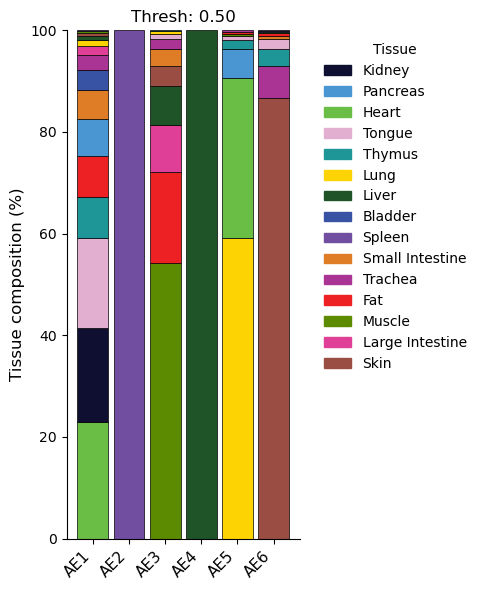

Tissue,Bladder,Fat,Heart,Kidney,Large Intestine,Liver,Lung,Muscle,Pancreas,Skin,Small Intestine,Spleen,Thymus,Tongue,Trachea
archetype,,,,,,,,,,,,,,,
1,3.793332,8.090418,22.860134,18.628638,1.837395,0.752597,1.222970,0.376298,7.243746,0.658522,5.846446,0.094075,8.090418,17.591955,2.913058
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000
3,0.000000,17.766896,0.000000,0.000000,9.357565,7.585866,0.598884,54.298828,0.000000,3.992561,3.383526,0.000000,0.199628,0.998140,1.818106
4,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.370493,31.491892,0.000000,0.000000,0.000000,59.093608,0.370493,5.742639,0.000000,0.000000,0.000000,1.852464,0.740986,0.337425
6,0.000000,0.611641,0.000000,0.000000,0.000000,0.000000,0.000000,0.244656,0.122328,86.608362,0.691120,0.122328,3.302861,1.834923,6.461781


In [28]:
plot_tissues(endothelial_weights, threshold=0.5, prefix='AE', save_path=RESULTS_ENDOTHELIAL_DIR, )


### Gini plots

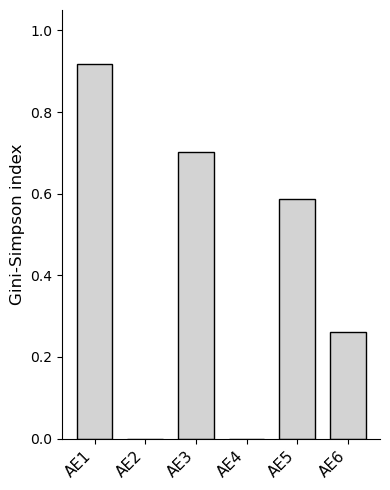

1    0.918691
2    0.000000
3    0.702726
4    0.000000
5    0.587021
6    0.261645
dtype: float64

In [29]:
 
plot_gini(endothelial_weights, threshold=0.5, prefix='AE', save_path=RESULTS_ENDOTHELIAL_DIR)


### archetype composition per tissue

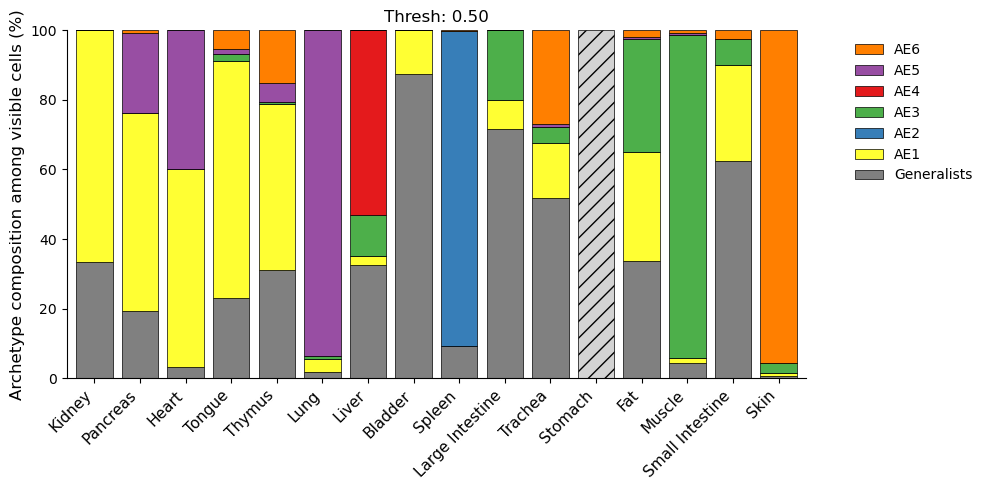

archetype,0,1,2,3,4,5,6
Tissue,,,,,,,
Kidney,33.333333,66.666667,0.000000,0.000000,0.000,0.000000,0.000000
Pancreas,19.259259,57.037037,0.000000,0.000000,0.000,22.962963,0.740741
Heart,3.278689,56.908665,0.000000,0.000000,0.000,39.812646,0.000000
Tongue,22.992701,68.248175,0.000000,1.824818,0.000,1.459854,5.474453
Thymus,31.111111,47.777778,0.000000,0.555556,0.000,5.555556,15.000000
Lung,1.759531,3.812317,0.000000,0.879765,0.000,93.548387,0.000000
Liver,32.500000,2.500000,0.000000,11.875000,53.125,0.000000,0.000000
Bladder,87.500000,12.500000,0.000000,0.000000,0.000,0.000000,0.000000
Spleen,9.242424,0.151515,90.454545,0.000000,0.000,0.000000,0.151515


In [30]:
plot_archetypes(endothelial_weights,include_generalists = True, threshold=0.5, prefix='AE', save_path=RESULTS_ENDOTHELIAL_DIR)


### PCA of archetype composition

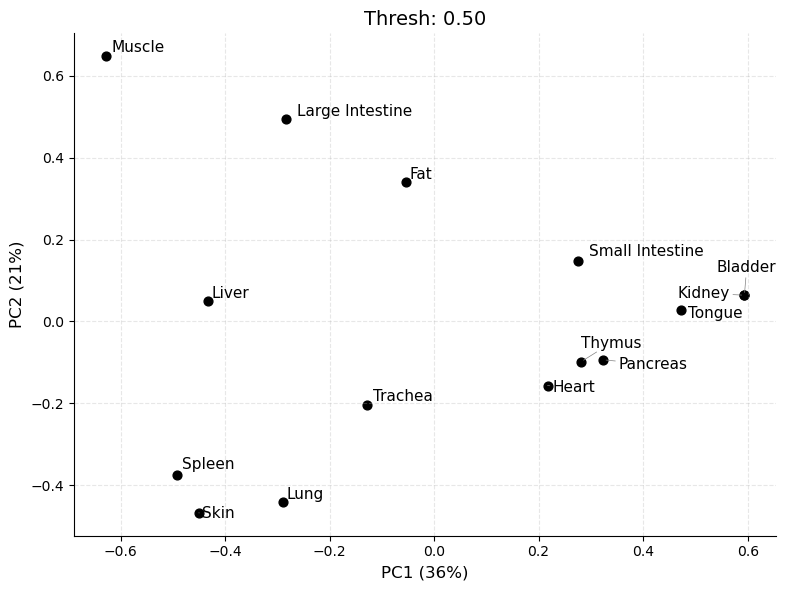

In [31]:
pca_df_endo = interactive_pca_wrapper(
    endothelial_weights,
    threshold=0.5,
    save_path=RESULTS_ENDOTHELIAL_DIR,
    cell_type_prefix="endothelial",
    include_generalists=False
)

## endo witout_splen_liver 

In [32]:
# Load Endothelial Data
endo_path = FIG3_DIR / 'endothelial' / 'without_liver'
adata_endo_path = FIG3_DIR / 'endothelial' /'without_liver'/ 'endothelial_without_liver.h5ad'

RESULTS_ENDOTHELIAL_DIR_witouut_spleen = RESULTS_DIR / "endothelial" / "without_liver"
RESULTS_ENDOTHELIAL_DIR_witouut_spleen.mkdir(parents=True, exist_ok=True)

adata_endo = ad.read_h5ad(adata_endo_path)
gene_expression_endo = adata_endo.X if isinstance(adata_endo.X, np.ndarray) else adata_endo.X.toarray()
archetypes_data_endo = loadmat(endo_path / "Endo_5_arcOrig.mat")['arcOrig']
Endo_meta = adata_endo.obs
validate_expression_archetypes(adata_endo, archetypes_data_endo, 5, "human endothelial without liver")


Validated human endothelial without liver: cells=9207, genes=8456, archetypes=5


In [33]:
endothelial_weights = process_weights(
    gene_expression_endo,
    archetypes_data_endo,
    Endo_meta,
    'tissue_in_publication',
    'Archetype'
)


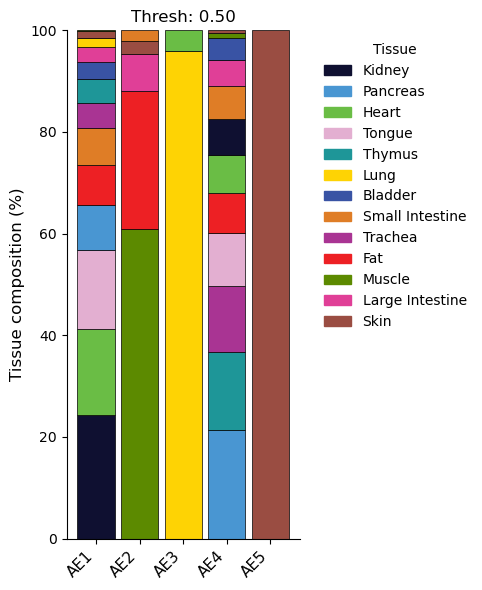

Tissue,Bladder,Fat,Heart,Kidney,Large Intestine,Lung,Muscle,Pancreas,Skin,Small Intestine,Thymus,Tongue,Trachea
archetype,,,,,,,,,,,,,
1,3.436613,7.883591,17.045602,24.260449,2.913067,1.70456,0.213070,8.948941,1.384955,7.222713,4.687541,15.447577,4.851321
2,0.000000,27.119302,0.000000,0.000000,7.255806,0.00000,60.925556,0.000000,2.600481,2.098855,0.000000,0.000000,0.000000
3,0.000000,0.000000,4.062500,0.000000,0.000000,95.93750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4.415674,7.848125,7.422258,7.228299,4.990632,0.00000,0.973411,21.415039,0.486705,6.530652,15.270383,10.342491,13.076330
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000


In [34]:
plot_tissues(
    endothelial_weights,
    threshold=0.5,
    prefix="AE",
    save_path=RESULTS_ENDOTHELIAL_DIR_witouut_spleen,
)


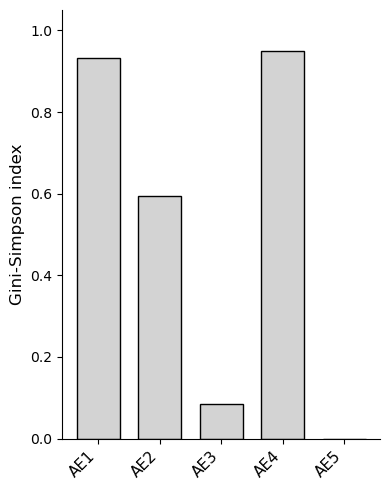

1    0.933527
2    0.594621
3    0.084445
4    0.950417
5    0.000000
dtype: float64

In [35]:
plot_gini(endothelial_weights, threshold=0.5, prefix='AE', save_path=RESULTS_ENDOTHELIAL_DIR_witouut_spleen)

